In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

In [13]:
heart_data = pd.read_csv("C:/Users/Shrinidhi.V/Downloads/heart_failure_clinical_records_dataset.csv")
print(heart_data.shape)
print(heart_data.head())

(299, 13)
    age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
0  75.0        0                       582         0                 20   
1  55.0        0                      7861         0                 38   
2  65.0        0                       146         0                 20   
3  50.0        1                       111         0                 20   
4  65.0        1                       160         1                 20   

   high_blood_pressure  platelets  serum_creatinine  serum_sodium  sex  \
0                    1  265000.00               1.9           130    1   
1                    0  263358.03               1.1           136    1   
2                    0  162000.00               1.3           129    1   
3                    0  210000.00               1.9           137    1   
4                    0  327000.00               2.7           116    0   

   smoking  time  DEATH_EVENT  
0        0     4            1  
1        0     6            1 

In [15]:
print(heart_data.isnull().sum())

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64


In [17]:
print(heart_data['DEATH_EVENT'].value_counts())

DEATH_EVENT
0    203
1     96
Name: count, dtype: int64


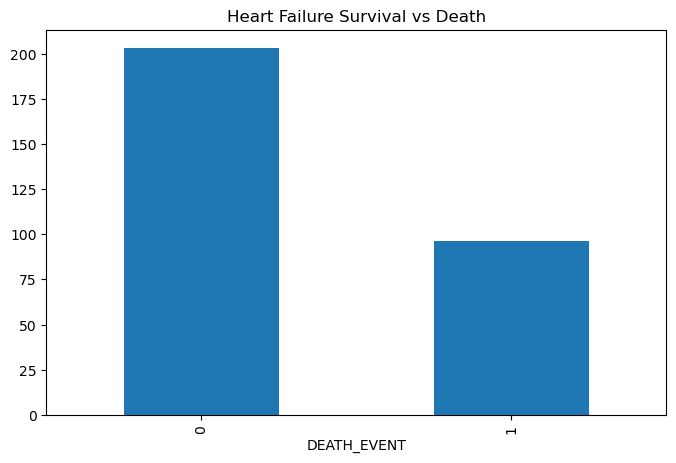

In [19]:
plt.figure(figsize=(8, 5))
heart_data['DEATH_EVENT'].value_counts().plot(kind='bar')
plt.title('Heart Failure Survival vs Death')
plt.show()

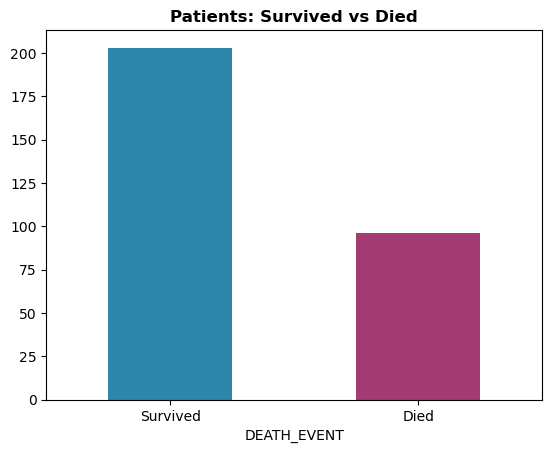

In [20]:
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3F7CAC', '#6B8F71']

heart_data['DEATH_EVENT'].value_counts().plot(kind='bar', color=[colors[0], colors[1]])
plt.title('Patients: Survived vs Died', fontweight='bold')
plt.xticks([0, 1], ['Survived', 'Died'], rotation=0)
plt.show()

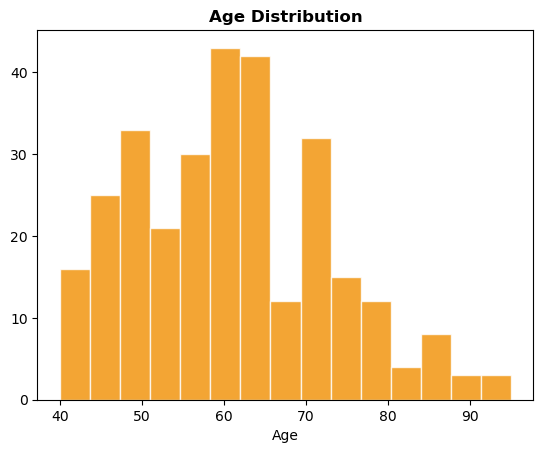

In [22]:
plt.hist(heart_data['age'], bins=15, color=colors[2], alpha=0.8, edgecolor='white')
plt.title('Age Distribution', fontweight='bold')
plt.xlabel('Age')
plt.show()

C:\Users\Shrinidhi.V\AppData\Local\Temp\ipykernel_9676\3674123936.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='DEATH_EVENT', y='ejection_fraction', data=heart_data, palette=[colors[0], colors[1]])


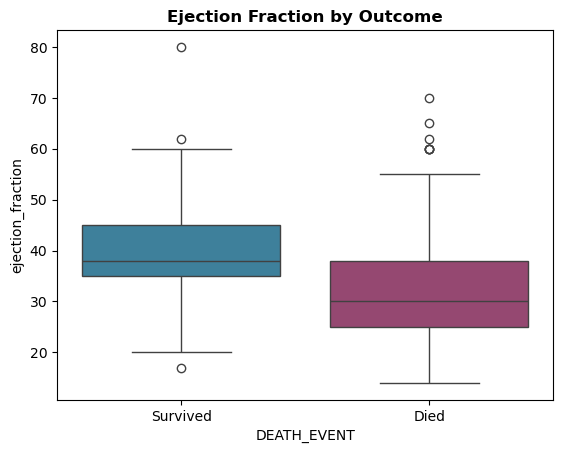

In [24]:
sns.boxplot(x='DEATH_EVENT', y='ejection_fraction', data=heart_data, palette=[colors[0], colors[1]])
plt.title('Ejection Fraction by Outcome', fontweight='bold')
plt.xticks([0, 1], ['Survived', 'Died'])
plt.show()

C:\Users\Shrinidhi.V\AppData\Local\Temp\ipykernel_9676\3342680627.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='DEATH_EVENT', y='serum_creatinine', data=heart_data, palette=[colors[0], colors[1]])


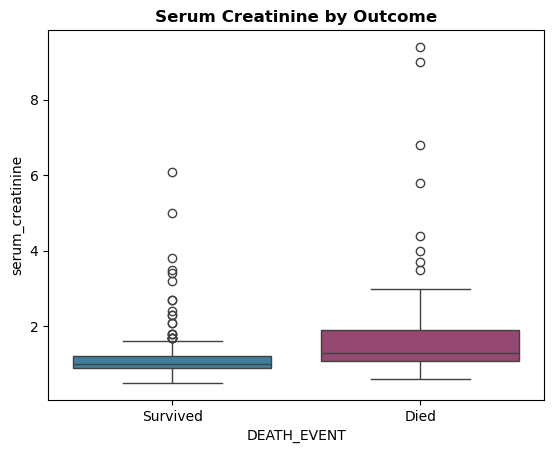

In [26]:
sns.boxplot(x='DEATH_EVENT', y='serum_creatinine', data=heart_data, palette=[colors[0], colors[1]])
plt.title('Serum Creatinine by Outcome', fontweight='bold')
plt.xticks([0, 1], ['Survived', 'Died'])
plt.show()

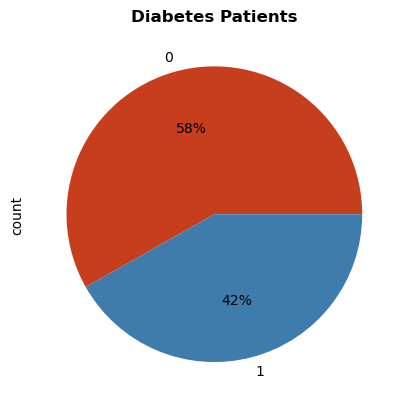

In [28]:
heart_data['diabetes'].value_counts().plot(kind='pie', autopct='%1.0f%%', colors=[colors[3], colors[4]])
plt.title('Diabetes Patients', fontweight='bold')
plt.show()

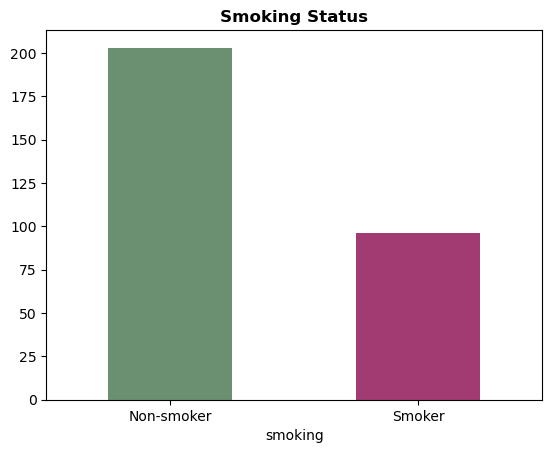

In [31]:
heart_data['smoking'].value_counts().plot(kind='bar', color=[colors[5], colors[1]])
plt.title('Smoking Status', fontweight='bold')
plt.xticks([0, 1], ['Non-smoker', 'Smoker'], rotation=0)
plt.show()

In [33]:
X = heart_data.drop('DEATH_EVENT', axis=1)
y = heart_data['DEATH_EVENT']

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [37]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [39]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

In [41]:
y_pred = rf_model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)

print(f"Model accuracy: {accuracy:.3f}")
print(classification_report(y_test, y_pred))

Model accuracy: 0.833
              precision    recall  f1-score   support

           0       0.84      0.93      0.88        41
           1       0.80      0.63      0.71        19

    accuracy                           0.83        60
   macro avg       0.82      0.78      0.79        60
weighted avg       0.83      0.83      0.83        60



                     feature  importance
11                      time    0.361383
7           serum_creatinine    0.154118
4          ejection_fraction    0.129121
6                  platelets    0.076820
0                        age    0.076779
2   creatinine_phosphokinase    0.074548
8               serum_sodium    0.066215
3                   diabetes    0.013931
5        high_blood_pressure    0.013373
9                        sex    0.011312
1                    anaemia    0.011203
10                   smoking    0.011198


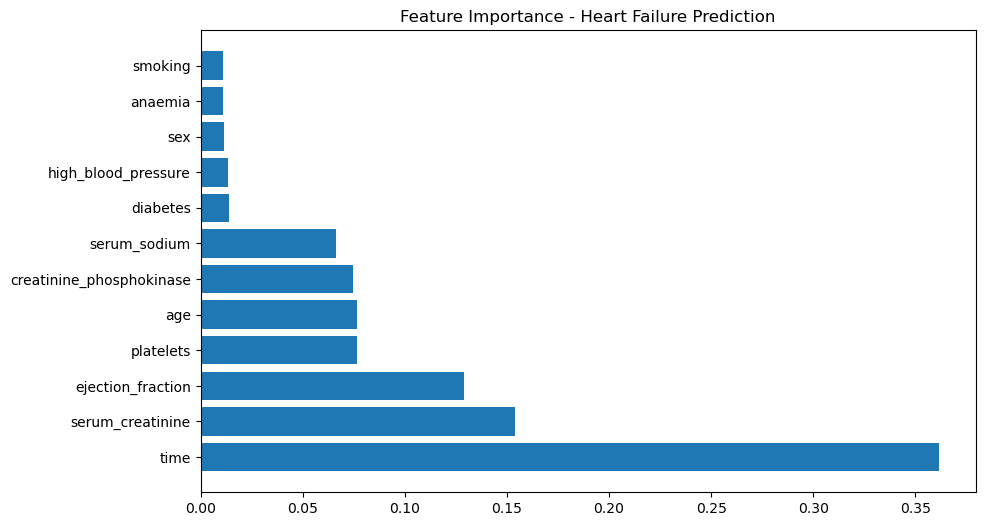

In [43]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)
print(feature_importance)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.title('Feature Importance - Heart Failure Prediction')
plt.show()

In [50]:
sample_patient = [[75, 0, 140, 1, 0, 266000, 1.9, 136, 1, 1, 12, 1]]
sample_scaled = scaler.transform(sample_patient)
prediction = rf_model.predict(sample_scaled)[0]
probability = rf_model.predict_proba(sample_scaled)[0]
print(f"Prediction: {'High Risk' if prediction == 1 else 'Lower Risk'}")
print(f"Confidence: {probability[1]:.2%}")

Prediction: High Risk
Confidence: 91.00%


C:\Users\Shrinidhi.V\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
